<a href="https://colab.research.google.com/github/MonishaPandhi/IB2AD0_Data_Science_GenerativeAI/blob/main/Copy_of_EDA_Practice_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("umitka/global-democracy-index")

print("Path to dataset files:", path)

100%|██████████| 3.31k/3.31k [00:00<00:00, 1.91MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/umitka/global-democracy-index/versions/1


In [ ]:
import os

# List files in the downloaded directory
files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]

if csv_files:
    # Assuming the main dataset is the first CSV found
    data_file = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file)

    print("First 20 rows of the dataset:")
    print(df.head(20).to_markdown(index=False, numalign="left", stralign="left"))
else:
    print("No CSV files found in the dataset directory.")

First 20 rows of the dataset:
| country_code   | country_name           | score_2018   | score_2022   |
|:---------------|:-----------------------|:-------------|:-------------|
| AFG            | Afghanistan            | 2.97         | 0.32         |
| AGO            | Angola                 | 3.62         | 3.96         |
| ALB            | Albania                | 5.98         | 6.41         |
| ARE            | United Arab Emirates   | 2.76         | 2.9          |
| ARG            | Argentina              | 7.02         | 6.85         |
| ARM            | Armenia                | 4.79         | 5.63         |
| AUS            | Australia              | 9.09         | 8.71         |
| AUT            | Austria                | 8.29         | 8.2          |
| AZE            | Azerbaijan             | 2.65         | 2.87         |
| BDI            | Burundi                | 2.33         | 2.13         |
| BEL            | Belgium                | 7.78         | 7.64         |
| BEN   

In [ ]:
print("Summary statistics for the dataset:")
print(df.describe().to_markdown(numalign="left", stralign="left"))

Summary statistics for the dataset:
|       | score_2018   | score_2022   |
|:------|:-------------|:-------------|
| count | 167          | 167          |
| mean  | 5.47856      | 5.29317      |
| std   | 2.1994       | 2.37586      |
| min   | 1.08         | 0.32         |
| 25%   | 3.545        | 3.11         |
| 50%   | 5.69         | 5.54         |
| 75%   | 7.175        | 7.1          |
| max   | 9.87         | 9.81         |


I have imported the dataset and examined the first 20 rows to see where I can drae insights from. I have decided I want to examine whether the world as a whole became more or less democratic between 2018 and 2022. Once calculating the summary statistics, I have checked all the values make sense.

Examining the summary statistics for both years, I can see that the mean reduced indivating that the world became less democratic on average between these two years. The standard deviation increased, suggesting that democracy scores became more dispersed, possibly reflecting widening inequality in democratic governance quality among countries.

AI prompts used:
- put the dataset in an easy to read dataframe showing the first 20 rows
- Show me the summary statistics for df


Number of null values before replacement:
|              | 0   |
|:-------------|:----|
| country_code | 0   |
| country_name | 0   |
| score_2018   | 0   |
| score_2022   | 0   |

Number of null values after replacement:
|              | 0   |
|:-------------|:----|
| country_code | 0   |
| country_name | 0   |
| score_2018   | 0   |
| score_2022   | 0   |
Null values have been replaced. Numerical columns were filled with their respective means, and non-numerical columns with their modes.


I checked the data for null values to minimise any error

AI prompt used: replace any null values in the data

In [ ]:
import numpy as np

# Calculate lower and upper bounds for score_2018
lower_bound_2018 = Q1_2018 - 1.5 * IQR_2018
upper_bound_2018 = Q3_2018 + 1.5 * IQR_2018

# Identify outliers for score_2018
outliers_2018 = df[(df['score_2018'] < lower_bound_2018) | (df['score_2018'] > upper_bound_2018)]

# Calculate lower and upper bounds for score_2022
lower_bound_2022 = Q1_2022 - 1.5 * IQR_2022
upper_bound_2022 = Q3_2022 + 1.5 * IQR_2022

# Identify outliers for score_2022
outliers_2022 = df[(df['score_2022'] < lower_bound_2022) | (df['score_2022'] > upper_bound_2022)]

# Print the number of outliers
print(f"Number of outliers in score_2018: {len(outliers_2018)}")
print(f"Number of outliers in score_2022: {len(outliers_2022)}")

Number of outliers in score_2018: 0
Number of outliers in score_2022: 0


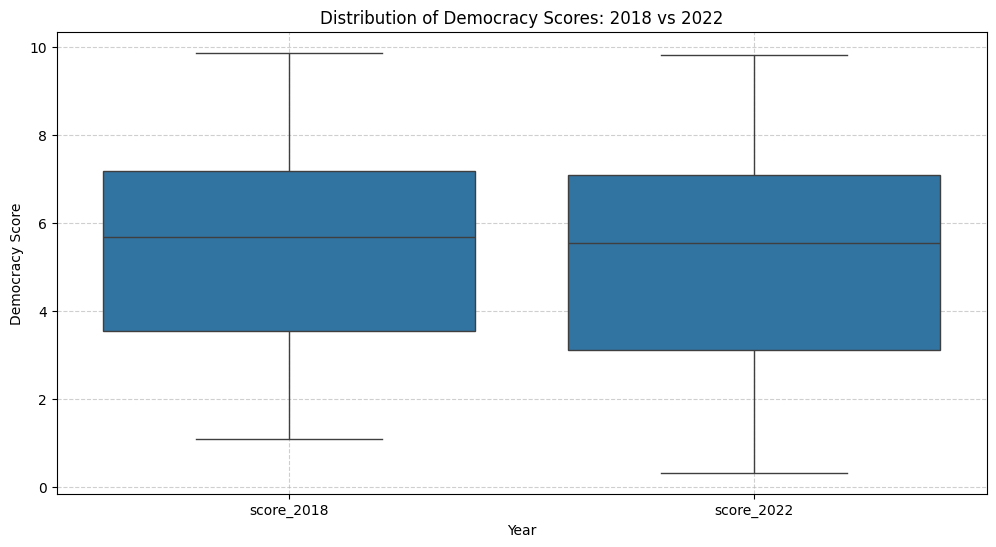

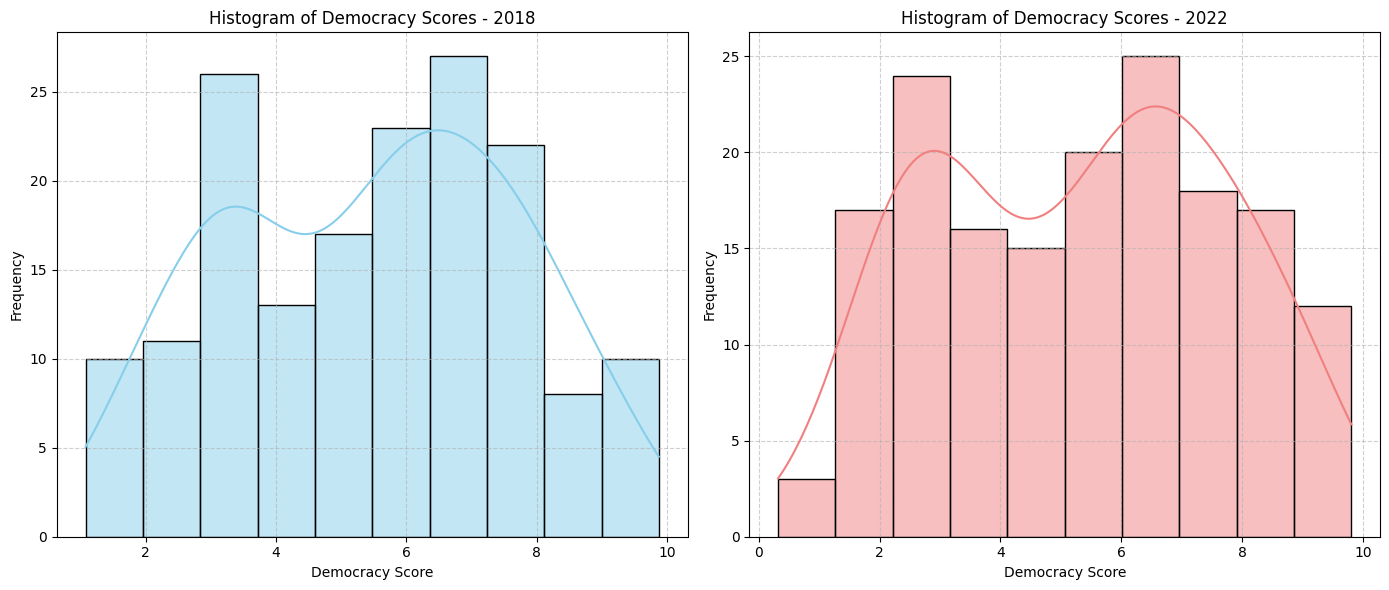

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted = df.melt(id_vars=['country_code', 'country_name'], value_vars=['score_2018', 'score_2022'],
                    var_name='year', value_name='democracy_score')

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='democracy_score', data=df_melted)
plt.title('Distribution of Democracy Scores: 2018 vs 2022')
plt.xlabel('Year')
plt.ylabel('Democracy Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['score_2018'], kde=True, bins=10, color='skyblue')
plt.title('Histogram of Democracy Scores - 2018')
plt.xlabel('Democracy Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.histplot(df['score_2022'], kde=True, bins=10, color='lightcoral')
plt.title('Histogram of Democracy Scores - 2022')
plt.xlabel('Democracy Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The box plot and histograms help to visualise what's been said previously. The absence of outliers suggests a relatively consistent distribution of democracy scores across countries for both years, indicating that there were no extreme values significantly deviating from the overall trend.

AI prompt: generate a box plot and histogram for 2018 and 2022

In [ ]:
# Calculate the change in democracy score
df['democracy_change'] = df['score_2022'] - df['score_2018']

# Sort by change in ascending order to find biggest decreases
biggest_decreases = df.sort_values(by='democracy_change', ascending=True).head(10)

# Sort by change in descending order to find biggest increases
biggest_increases = df.sort_values(by='democracy_change', ascending=False).head(10)

print("Top 10 countries with the biggest decrease in democracy score (2018-2022):")
print(biggest_decreases[['country_name', 'score_2018', 'score_2022', 'democracy_change']].to_markdown(index=False, numalign="left", stralign="left"))

print("\nTop 10 countries with the biggest increase in democracy score (2018-2022):")
print(biggest_increases[['country_name', 'score_2018', 'score_2022', 'democracy_change']].to_markdown(index=False, numalign="left", stralign="left"))

Top 10 countries with the biggest decrease in democracy score (2018-2022):
| country_name    | score_2018   | score_2022   | democracy_change   |
|:----------------|:-------------|:-------------|:-------------------|
| Myanmar         | 3.83         | 0.74         | -3.09              |
| Afghanistan     | 2.97         | 0.32         | -2.65              |
| Mali            | 5.41         | 3.23         | -2.18              |
| Haiti           | 4.91         | 2.81         | -2.1               |
| Burkina Faso    | 4.75         | 3.08         | -1.67              |
| Kyrgyz Republic | 5.11         | 3.62         | -1.49              |
| Benin           | 5.74         | 4.28         | -1.46              |
| China           | 3.32         | 1.94         | -1.38              |
| Bolivia         | 5.7          | 4.51         | -1.19              |
| Belarus         | 3.13         | 1.99         | -1.14              |

Top 10 countries with the biggest increase in democracy score (2018-2022

/tmp/ipython-input-3863892978.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


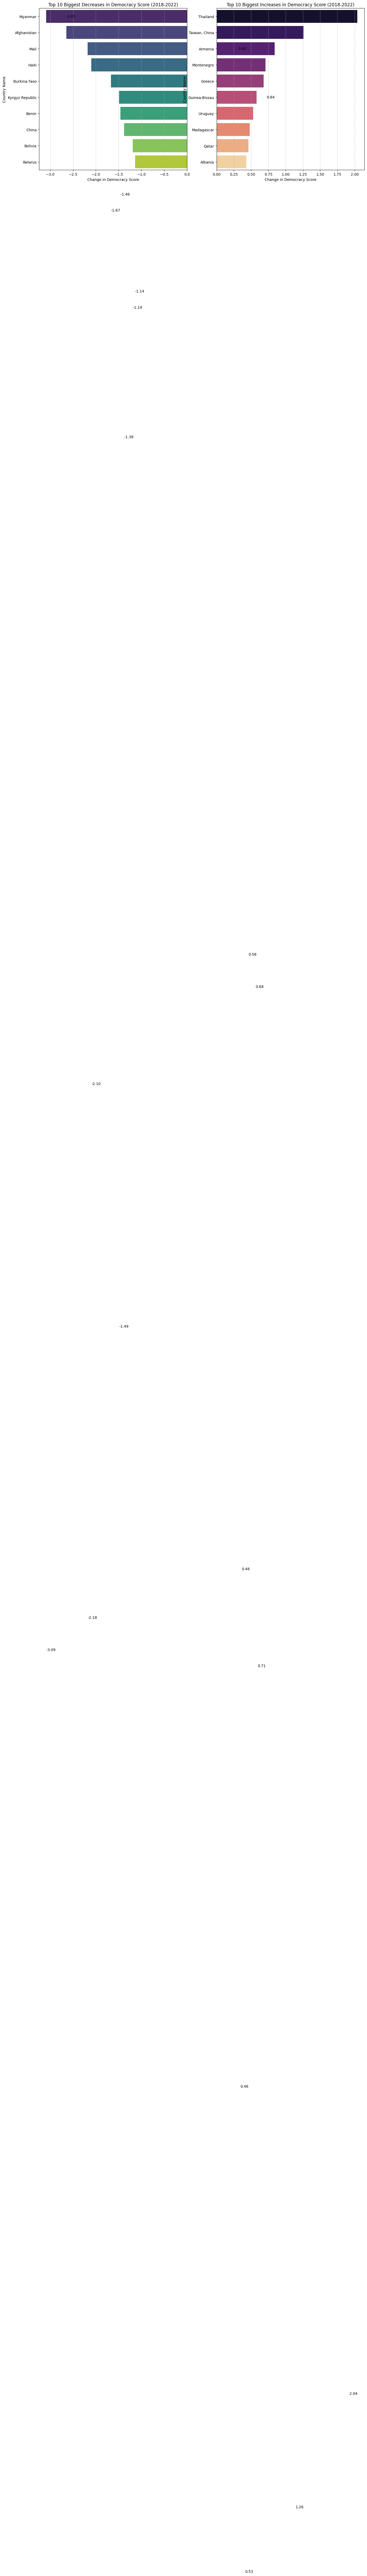

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots, slightly increased figsize to help with tight_layout
plt.figure(figsize=(16, 8))

# Plot for biggest decreases
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='democracy_change', y='country_name', data=biggest_decreases, hue='country_name', palette='viridis', legend=False)
plt.title('Top 10 Biggest Decreases in Democracy Score (2018-2022)')
plt.xlabel('Change in Democracy Score')
plt.ylabel('Country Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
# Add annotations
for index, row in biggest_decreases.iterrows():
    plt.text(row['democracy_change'], index, f"{row['democracy_change']:.2f}", color='black', ha="left", va="center")

# Plot for biggest increases
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='democracy_change', y='country_name', data=biggest_increases, hue='country_name', palette='magma', legend=False)
plt.title('Top 10 Biggest Increases in Democracy Score (2018-2022)')
plt.xlabel('Change in Democracy Score')
plt.ylabel('Country Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
# Add annotations
for index, row in biggest_increases.iterrows():
    plt.text(row['democracy_change'], index, f"{row['democracy_change']:.2f}", color='black', ha="right", va="center")

plt.tight_layout()
plt.show()

Upon further analysis of investigating the specific countries that experienced the largest decreases or increases in democracy scores the visually plotting them in a bar chart, it is clear that Thailand became increasingly more democractic compared to other countries over the period (has the largest increase in its democracy score) and Myanmar became increasingly less democratic compared to other countries during 2018 to 2022. I would have to consult a subject matter expert to discuss the factors behind the stark changes in democracy scores.

AI prompts used:
- Show me the countries with the biggest change in democracy scores
- Visualise the countries with the biggest democracy score changes